# Vary accretion rate in BEoRN

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import beorn
from beorn import run

Exponential mass accretion

$$M(z) = M(z_0) e^{-\alpha (z-z_0)} $$

In [61]:
param = beorn.par()

# Halo Mass bins
param.sim.Mh_bin_min = 1e7
param.sim.Mh_bin_max = 1e15
param.sim.binn = 40  # nbr of halo mass bin

# name your simulation
param.sim.model_name = 'accretion'
# Nbr of cores to use
param.sim.cores = 1  

# simulation redshifts
param.solver.Nz = [7.72]  

# cosmo
param.cosmo.Om = 0.31
param.cosmo.Ob = 0.045
param.cosmo.Ol = 0.69
param.cosmo.h = 0.68

# Source parameters
# lyman-alpha 
param.source.N_al = 9690  # 1500
param.source.alS_lyal = 0.0
# ion
param.source.Nion = 3000  
# xray
param.source.E_min_xray = 500
param.source.E_max_xray = 10000
param.source.E_min_sed_xray = 200
param.source.E_max_sed_xray = 10000
param.source.alS_xray = 1.5
param.source.cX = 3.4e40

# fesc
param.source.f0_esc = 0.2
param.source.pl_esc = 0.5

# fstar
param.source.f_st = 0.14
param.source.g1 = 0.49
param.source.g2 = -0.61
param.source.g3 = 4
param.source.g4 = -4
param.source.Mp = 1.6e11 * param.cosmo.h
param.source.Mt = 1e9

# Minimum star forming halo
param.source.M_min = 1e8

# Mass Accretion Rate model (EXP or EPS)
param.source.MAR = 'EXP'

In [66]:
alpha_list = [0.1, 0.8, 1.3]
z_list = [13, 10, 8]
ind_M = 20


In [67]:
for alpha in alpha_list:
    param.sim.model_name = f'accretion_{np.round(10*alpha).astype(int):02d}'
    param.source.alpha_MAR = alpha
    run.compute_profiles(param)

Computing Temperature (Tk), Lyman-α and ionisation fraction (xHII) profiles...
param.solver.Nz is given as a list.
param.solver.fXh is set to constant. We will assume f_X,h = 2e-4**0.225
...  Profiles stored in dir ./profiles.
 
It took 00:00:20 to compute the profiles.
Computing Temperature (Tk), Lyman-α and ionisation fraction (xHII) profiles...
param.solver.Nz is given as a list.
param.solver.fXh is set to constant. We will assume f_X,h = 2e-4**0.225
...  Profiles stored in dir ./profiles.
 
It took 00:00:20 to compute the profiles.
Computing Temperature (Tk), Lyman-α and ionisation fraction (xHII) profiles...
param.solver.Nz is given as a list.
param.solver.fXh is set to constant. We will assume f_X,h = 2e-4**0.225
...  Profiles stored in dir ./profiles.
 
It took 00:00:16 to compute the profiles.


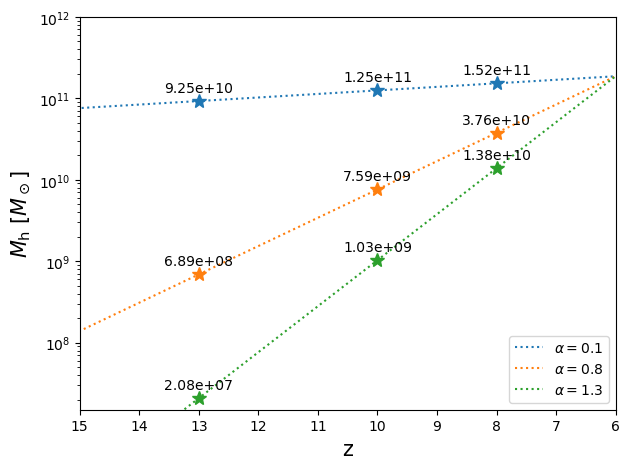

In [113]:

for alpha in alpha_list:
    profile = beorn.load_f(f'./profiles/accretion_{np.round(10*alpha).astype(int):02d}.pkl')
    zz = profile.z_history
    p = plt.semilogy(zz, profile.Mh_history[:, ind_M] / 0.68, ls=':', label=r'$\alpha=%.1f$'%alpha)

    zi_list = []
    Mhi_list = []
    for zi in z_list:
        ind_z = np.argmin(np.abs(zz - zi))
        zi_list.append(profile.z_history[ind_z])
        Mh_i = profile.Mh_history[ind_z, ind_M]/0.68
        Mhi_list.append(Mh_i)
        plt.text(zi, Mh_i*(1.3), '%.2e'%Mh_i, ha='center')
    plt.semilogy(zi_list, Mhi_list, '*', color=p[0].get_color(), ms=10)
    

plt.xlim(15, 6)
plt.ylim(1.5e7,1e12)
plt.xlabel('z', fontsize=15)
plt.ylabel(r'$M_\mathrm{h}$ [$M_\odot$]', fontsize=15)
plt.legend(loc='lower right')
plt.tight_layout()

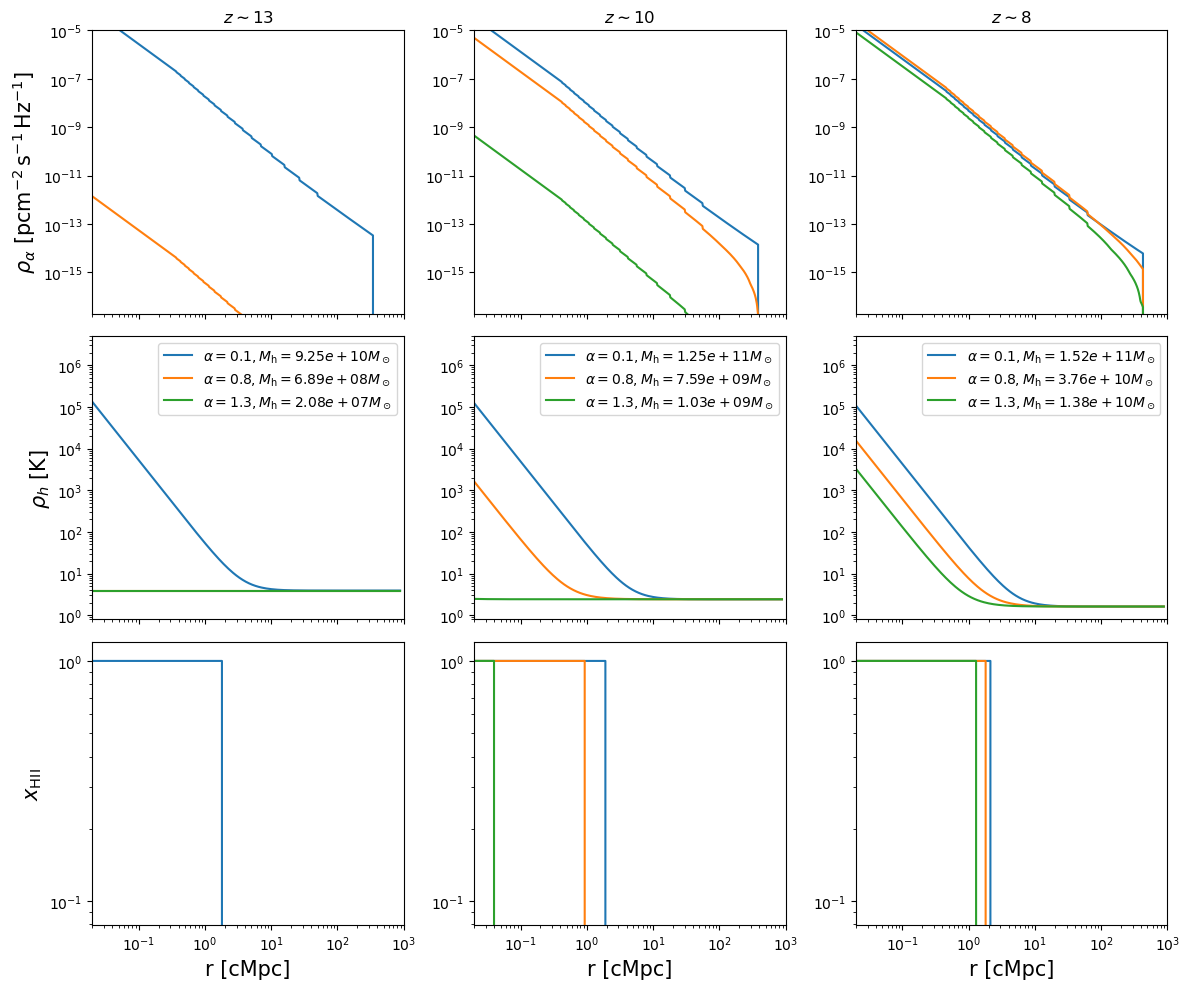

In [87]:
fig, axes = plt.subplots(3, 3, sharex=True, sharey=False, figsize=(12, 10))
    
for alpha in alpha_list:
    profile = beorn.load_f(f'./profiles/accretion_{np.round(10*alpha).astype(int):02d}.pkl')
    zz = profile.z_history
    Mh_list = []

    r_lyal_phys = profile.r_lyal
    co_radial_grid = profile.r_grid_cell
    for i, zi in enumerate(z_list):
        ind_z = np.argmin(np.abs(zz - zi))
        zzi = profile.z_history[ind_z]
        Mh_i = profile.Mh_history[ind_z, ind_M]
        lyal_profile = profile.rho_alpha[ind_z, :, ind_M]
        axes[0,i].loglog(r_lyal_phys * (1. + zzi) / 0.68, lyal_profile, 
                       label=r'$\alpha = %.1f, M_\mathrm{h} = %.2e M_\odot$'%(alpha, Mh_i/0.68))
        axes[0,i].set_ylim(2e-17, 1e-5)
        axes[0,i].set_title(r'$z\sim%.0f$'%zi)

        T_adiab_z = beorn.cosmo.T_adiab(zi, param)
        temp_profile = profile.rho_heat[ind_z, :, ind_M] + T_adiab_z
        axes[1,i].loglog(co_radial_grid / 0.68, temp_profile, 
                       label=r'$\alpha = %.1f, M_\mathrm{h} = %.2e M_\odot$'%(alpha, Mh_i/0.68))
        axes[1,i].set_xlim(2e-2, 1e2)
        axes[1,i].set_ylim(0.8, 5e6)
        axes[1,i].legend(loc='upper right')

        x_HII_profile = np.zeros((len(co_radial_grid)))
        x_HII_profile[np.where(co_radial_grid < profile.R_bubble[ind_z, ind_M])] = 1
        axes[2,i].loglog(co_radial_grid / 0.68, x_HII_profile, 
                       label=r'$\alpha = %.1f, M_\mathrm{h} = %.2e M_\odot$'%(alpha, Mh_i/0.68))
        axes[2,i].set_xlim(2e-2, 1e3)
        axes[2,i].set_ylim(0, 1.2)
        
        axes[2,i].set_xlabel('r [cMpc]', fontsize=15)
axes[0,0].set_ylabel(r'$\rho_\alpha$ [$\mathrm{pcm^{-2}\,s^{-1}\,Hz^{-1}}$]', fontsize=15)
axes[1,0].set_ylabel(r'$\rho_h$ [K]', fontsize=15)
axes[2,0].set_ylabel(r'$x_\mathrm{HII}$', fontsize=15)
plt.tight_layout()